# Lab 1 — Inside a Foundation Model

**Course:** Foundation Models: Architecture, Training and Alignment  
**Goal:** understand the basic pipeline: Text → Tokens → Embeddings → Attention → Output.

Run the cells, change the examples, and answer the reflection questions at the end.

In [1]:
!pip -q install transformers sentence-transformers scikit-learn matplotlib accelerate

## Part A — Tokenization

A model does not see words. It sees token IDs.

In [2]:
from transformers import AutoTokenizer

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
gpt_tokenizer = AutoTokenizer.from_pretrained("gpt2")

texts = [
    "Transformers are amazing!",
    "internationalization",
    "The price is 39.99 dollars.",
    "https://www.example.com/foundation-models",
    "שלום עולם",
    "AI 🚀 is changing everything"
]

for text in texts:
    print("\nTEXT:", repr(text))
    print("BERT tokens:", bert_tokenizer.tokenize(text))
    print("BERT token count:", len(bert_tokenizer.tokenize(text)))
    print("GPT-2 tokens:", gpt_tokenizer.tokenize(text))
    print("GPT-2 token count:", len(gpt_tokenizer.tokenize(text)))


TEXT: 'Transformers are amazing!'
BERT tokens: ['transformers', 'are', 'amazing', '!']
BERT token count: 4
GPT-2 tokens: ['Transform', 'ers', 'Ġare', 'Ġamazing', '!']
GPT-2 token count: 5

TEXT: 'internationalization'
BERT tokens: ['international', '##ization']
BERT token count: 2
GPT-2 tokens: ['international', 'ization']
GPT-2 token count: 2

TEXT: 'The price is 39.99 dollars.'
BERT tokens: ['the', 'price', 'is', '39', '.', '99', 'dollars', '.']
BERT token count: 8
GPT-2 tokens: ['The', 'Ġprice', 'Ġis', 'Ġ39', '.', '99', 'Ġdollars', '.']
GPT-2 token count: 8

TEXT: 'https://www.example.com/foundation-models'
BERT tokens: ['https', ':', '/', '/', 'www', '.', 'example', '.', 'com', '/', 'foundation', '-', 'models']
BERT token count: 13
GPT-2 tokens: ['https', '://', 'www', '.', 'example', '.', 'com', '/', 'foundation', '-', 'models']
GPT-2 token count: 11

TEXT: 'שלום עולם'
BERT tokens: ['ש', '##ל', '##ו', '##ם', 'ע', '##ו', '##ל', '##ם']
BERT token count: 8
GPT-2 tokens: ['×©', '×ľ',

 **answers:**
1. Most tokens: the URL (13 BERT tokens / 11 GPT-2 tokens) - no natural word boundaries, so every `:`, `/`, `.` becomes its own token. The Hebrew sentence ties with it at 11 GPT-2 tokens.
2. The Hebrew text: it did **not** become `[UNK]` - both tokenizers lack Hebrew subwords, so they fall back to one token per letter (8 BERT tokens for 2 words). The emoji is the actual `[UNK]` case here.
3. Why tokenization affects cost: API pricing, context windows, and compute all scale with token count, so a poorly-tokenized language/format costs more for the same meaning.

### Your task
Add three examples of your own: one in Hebrew, one technical sentence, and one with numbers or a URL.

In [3]:
# My own examples, all from the finance domain (same domain as the search dataset below).
my_texts = [
    "הריבית במשק עלתה והמשכנתא שלי התייקרה",              # Hebrew example
    "The ETF's annualized Sharpe ratio was 1.42 after rebalancing.",  # technical example
    "Bitcoin traded at 67,250 dollars, see https://www.coindesk.com/price/btc"  # numbers / URL example
]

for text in my_texts:
    if not text:
        continue
    print("\nTEXT:", repr(text))
    print("BERT:", bert_tokenizer.tokenize(text))
    print("GPT-2:", gpt_tokenizer.tokenize(text))

# Hebrew doesn't hit [UNK] here - it splits into single-letter tokens instead.
# The emoji above was the actual [UNK] case.


TEXT: 'הריבית במשק עלתה והמשכנתא שלי התייקרה'
BERT: ['ה', '##ר', '##י', '##ב', '##י', '##ת', 'ב', '##מ', '##ש', '##ק', 'ע', '##ל', '##ת', '##ה', 'ו', '##ה', '##מ', '##ש', '##כ', '##נ', '##ת', '##א', 'ש', '##ל', '##י', 'ה', '##ת', '##י', '##י', '##ק', '##ר', '##ה']
GPT-2: ['×Ķ', '×¨', '×Ļ×', 'ĳ', '×Ļ×', 'ª', 'Ġ×', 'ĳ', '×ŀ', '×©', '×', '§', 'Ġ×', '¢', '×ľ', '×ª', '×Ķ', 'Ġ×', 'ķ', '×Ķ', '×ŀ', '×©', '×', 'Ľ', '×', 'ł', '×ª', '×Ĳ', 'Ġ×', '©', '×ľ', '×Ļ', 'Ġ×', 'Ķ', '×ª', '×Ļ', '×Ļ×', '§', '×¨', '×Ķ']

TEXT: "The ETF's annualized Sharpe ratio was 1.42 after rebalancing."
BERT: ['the', 'et', '##f', "'", 's', 'annual', '##ized', 'sharpe', 'ratio', 'was', '1', '.', '42', 'after', 're', '##bala', '##nc', '##ing', '.']
GPT-2: ['The', 'ĠETF', "'s", 'Ġannual', 'ized', 'ĠShar', 'pe', 'Ġratio', 'Ġwas', 'Ġ1', '.', '42', 'Ġafter', 'Ġreb', 'al', 'ancing', '.']

TEXT: 'Bitcoin traded at 67,250 dollars, see https://www.coindesk.com/price/btc'
BERT: ['bit', '##co', '##in', 'traded', 'at', '67', ',', '250

## Part B — Embeddings and Semantic Similarity

Embeddings represent text as vectors. Similar meanings should have similar vectors.

In [4]:
from sentence_transformers import SentenceTransformer, util

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

documents = [
    "A dog is running in the park.",
    "A puppy is playing outside.",
    "The stock market dropped today.",
    "Investors are worried about inflation.",
    "I ate pizza for dinner.",
    "The patient received antibiotics."
]

query = "A small dog is playing."

doc_embeddings = embedding_model.encode(documents)
query_embedding = embedding_model.encode(query)

scores = util.cos_sim(query_embedding, doc_embeddings)[0]

for doc, score in sorted(zip(documents, scores), key=lambda x: x[1], reverse=True):
    print(f"{score:.3f} | {doc}")

0.633 | A puppy is playing outside.
0.365 | A dog is running in the park.
0.132 | The stock market dropped today.
0.035 | I ate pizza for dinner.
0.009 | The patient received antibiotics.
-0.092 | Investors are worried about inflation.


### Your task
Create your own mini semantic search dataset with at least 10 short documents from a domain you care about.

In [5]:
# 10 finance docs: inflation/rates/gold, two near-duplicate stock sentences,
# an off-topic distractor, and one Hebrew sentence added on purpose.
my_documents = [
    "Rising inflation slowly erodes the value of cash savings.",
    "Index funds are a low-cost way to invest for the long term.",
    "The central bank raised interest rates to fight inflation.",
    "Gold is often seen as a safe haven when prices are rising.",
    "Tech stocks fell sharply after the earnings report.",
    "Shares of technology companies dropped following weak earnings.",
    "A monthly budget helps you control your spending habits.",
    "Bitcoin's price is extremely volatile compared to bonds.",
    "My cat knocked a cup of coffee off the kitchen table.",
    "השקל התחזק מול הדולר בעקבות העלאת הריבית"
]
my_query = "Which investments protect savings when prices rise?"

if my_documents and my_query:
    my_doc_embeddings = embedding_model.encode(my_documents)
    my_query_embedding = embedding_model.encode(my_query)
    my_scores = util.cos_sim(my_query_embedding, my_doc_embeddings)[0]
    for doc, score in sorted(zip(my_documents, my_scores), key=lambda x: x[1], reverse=True)[:3]:
        print(f"{score:.3f} | {doc}")

# Top results match the query's meaning (inflation/gold/rates), not its wording.
# The Hebrew doc ranks low because the embedding model is English-only.

0.471 | Rising inflation slowly erodes the value of cash savings.
0.470 | Index funds are a low-cost way to invest for the long term.
0.439 | Gold is often seen as a safe haven when prices are rising.


## Optional visualization

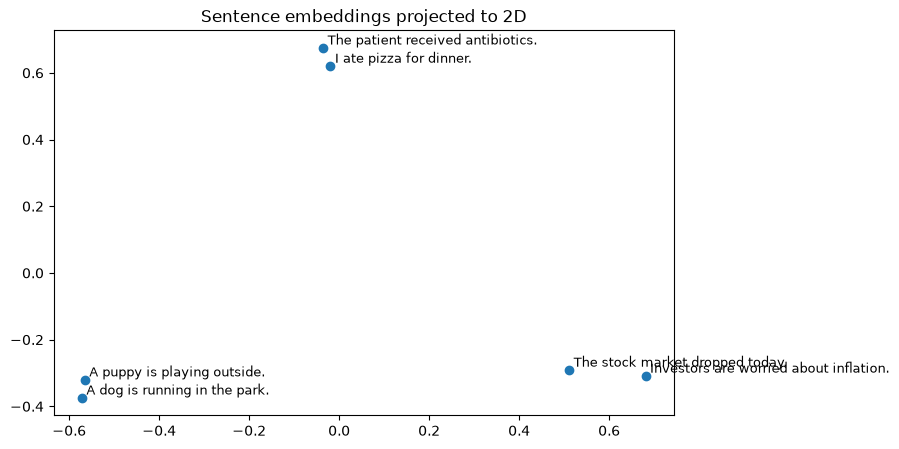

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

points = PCA(n_components=2).fit_transform(doc_embeddings)
plt.figure(figsize=(8, 5))
plt.scatter(points[:, 0], points[:, 1])
for i, doc in enumerate(documents):
    plt.text(points[i, 0] + 0.01, points[i, 1] + 0.01, doc, fontsize=9)
plt.title("Sentence embeddings projected to 2D")
plt.show()

## Part C — Attention Visualization

Attention lets each token attend to other tokens. This visualization is an intuition, not a complete explanation.

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


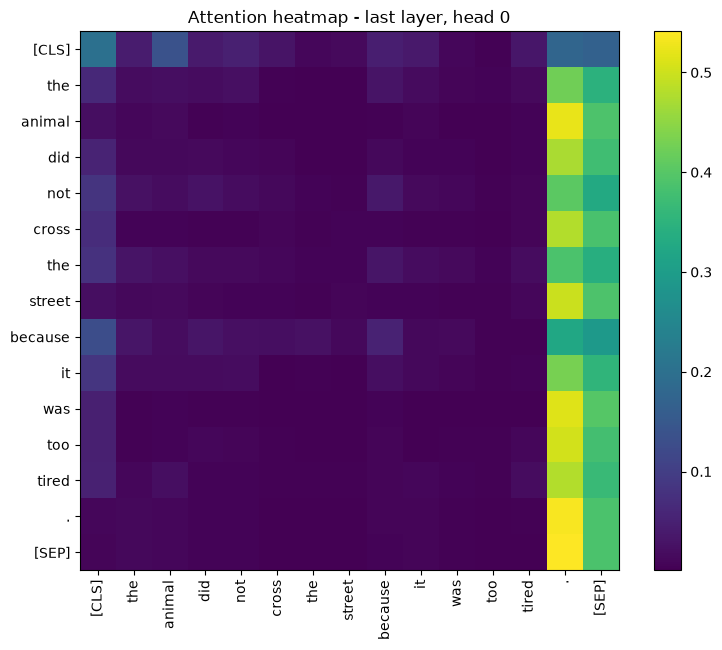

In [7]:
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name, output_attentions=True)

text = "The animal did not cross the street because it was too tired."
inputs = tokenizer(text, return_tensors="pt")
outputs = bert_model(**inputs)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
attention = outputs.attentions[-1][0, 0].detach().numpy()

plt.figure(figsize=(9, 7))
plt.imshow(attention)
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.colorbar()
plt.title("Attention heatmap - last layer, head 0")
plt.show()

### Your task
Change the sentence. Try different heads and layers.

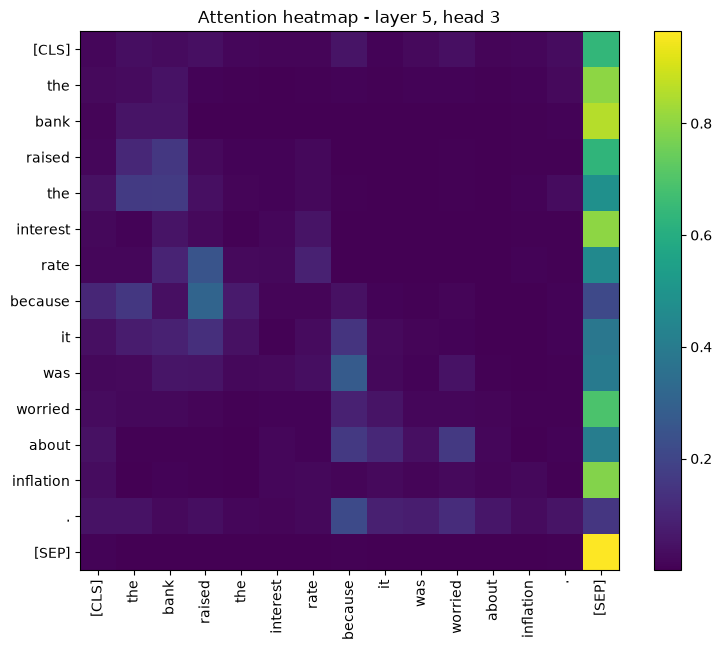

In [8]:
# New sentence with an ambiguous "it"; using a middle layer/head this time.
my_sentence = "The bank raised the interest rate because it was worried about inflation."
my_inputs = tokenizer(my_sentence, return_tensors="pt")
my_outputs = bert_model(**my_inputs)
my_tokens = tokenizer.convert_ids_to_tokens(my_inputs["input_ids"][0])

layer = 5
head = 3

attention = my_outputs.attentions[layer][0, head].detach().numpy()
plt.figure(figsize=(9, 7))
plt.imshow(attention)
plt.xticks(range(len(my_tokens)), my_tokens, rotation=90)
plt.yticks(range(len(my_tokens)), my_tokens)
plt.colorbar()
plt.title(f"Attention heatmap - layer {layer}, head {head}")
plt.show()

# In this head, "it" puts noticeable weight on "bank" - the coreference a human would resolve.

## Part D — GPT vs BERT

GPT-style models generate continuations. BERT-style models fill masked tokens.

In [9]:
from transformers import pipeline

text_generator = pipeline("text-generation", model="gpt2")
mask_filler = pipeline("fill-mask", model="bert-base-uncased")

print("GPT continuation:")
print(text_generator("Foundation models are", max_new_tokens=30, pad_token_id=50256)[0]["generated_text"])

print("\nBERT masked prediction:")
for item in mask_filler("Foundation models are [MASK] for modern AI.")[:5]:
    print(item["token_str"], item["score"])

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


GPT continuation:


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Foundation models are a way to build a more comprehensive vision of the future. Our vision is to be a global organization that works for everyone. We have a lot of

BERT masked prediction:


used 0.117645263671875
essential 0.10482113063335419
important 0.09996914863586426
useful 0.06686930358409882
needed 0.03841559961438179


## Challenge — Mini Semantic Search Engine

A tiny search engine over the finance documents from Part B: the user types a query, the code returns the three most similar documents. This is the intuition behind the retrieval step of RAG systems.

In [10]:
def semantic_search(query, documents, model, top_k=3):
    # This is the retrieval step of RAG: embed everything, rank by cosine similarity.
    doc_embeddings = model.encode(documents)
    query_embedding = model.encode(query)
    scores = util.cos_sim(query_embedding, doc_embeddings)[0]
    ranked = sorted(zip(documents, scores), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]

for search_query in [
    "How can I keep my money safe from inflation?",
    "What happened to technology shares?"
]:
    print(f"\nQUERY: {search_query}")
    for doc, score in semantic_search(search_query, my_documents, embedding_model):
        print(f"  {score:.3f} | {doc}")


QUERY: How can I keep my money safe from inflation?


  0.567 | Rising inflation slowly erodes the value of cash savings.
  0.486 | The central bank raised interest rates to fight inflation.
  0.394 | Gold is often seen as a safe haven when prices are rising.

QUERY: What happened to technology shares?


  0.699 | Shares of technology companies dropped following weak earnings.
  0.547 | Tech stocks fell sharply after the earnings report.
  0.220 | Index funds are a low-cost way to invest for the long term.


## Reflection questions

Write short answers:

1. What surprised you about tokenization?
2. What is the difference between semantic similarity and factual correctness?
3. Where did you see the first building block of RAG?
4. Does an attention map prove that a model understands a sentence? Why or why not?
5. What component from this lab could be useful in your final project?

### Answers

**1. What surprised you about tokenization?**
That one word is rarely one token, and that "no vocabulary for this language" doesn't necessarily mean `[UNK]`. Common English words survive intact, but "internationalization" splits into several subword pieces, numbers and URLs shatter into many fragments, and Hebrew doesn't collapse into `[UNK]` in bert-base-uncased at all - it degrades to one token per Hebrew *letter*, which is far less efficient than English subwords but doesn't lose information. `[UNK]` was reserved for something with truly no vocab entry, like the 🚀 emoji. The tokenizer's vocabulary quietly decides how "expensive" each language and domain is.

**2. What is the difference between semantic similarity and factual correctness?**
Cosine similarity only measures how close two texts are in meaning-space, not whether either is true. "Gold always protects against inflation" and "Gold never protects against inflation" would embed very close to each other while contradicting each other. Retrieval finds *relevant* text, not *correct* text — verifying facts is a separate problem.

**3. Where did you see the first building block of RAG?**
In Part B and the semantic search challenge: embedding a document collection, embedding a query, and ranking documents by cosine similarity. That is exactly the "Retrieval" step of Retrieval-Augmented Generation — the only missing piece is handing the top documents to a generative model as context.

**4. Does an attention map prove that a model understands a sentence? Why or why not?**
No. A heatmap shows one head in one layer out of 144 in BERT-base, and attention weights are an internal mixing mechanism, not an explanation of the final prediction. Seeing "it" attend to "bank" is suggestive intuition, but the model's actual behavior emerges from all heads, all layers, and the feed-forward computations together.

**5. What component from this lab could be useful in your final project?**
The sentence-embedding semantic search. A `semantic_search()` over domain documents (e.g., financial reports) is a ready-made retriever for a RAG pipeline: retrieve the top-k relevant passages, then let a generative model answer grounded in them.